In [1]:
from utils import *
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Input, Model
from tensorflow.keras.losses import Huber
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization, Flatten
from tensorflow.keras.layers import Bidirectional, LSTM 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import Callback
import TSFEDL.models_keras as TSFEDL # A python library for time series spatio-temporal feature extraction and prediction using deep learning # https://github.com/ari-dasci/S-TSFE-DL
from scipy.stats import f_oneway
from sklearn.model_selection import TimeSeriesSplit
import time
import json
import re

Using cuda (NVIDIA GeForce RTX 2060)


In [2]:
# load data
df = load_df()

# calcula las fechas de los datasets de TRAIN, VAL y TEST
dates = calulate_train_validation_test_dates(df)

# scale df
df_scaled, target_scaler  = scale_df(df, dates)

# create rolling window for all features
df_scaled_window = window_df(df_scaled)

# split in train / validation / test
df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test = split_df(df_scaled_window, dates)

# create tensors 3d: (batch_size, sequence_length, n_features), (batch_size, 1)
X_train, y_train = to_tensor3d_df(df_scaled_window_train) 
X_validation, y_validation = to_tensor3d_df(df_scaled_window_validation)
X_test, y_test = to_tensor3d_df(df_scaled_window_test)

# shape 
print(X_train.shape) # expected: (batch_size, sequence_length, n_features)
print(y_train.shape) # expected  (batch_size, 1)
 


torch.Size([24406, 64, 15])
torch.Size([24406])


In [ ]:

# hyperparametros
num_epochs = 50
learning_rate = 0.00005
loss_fn = Huber()
batch_size = 256
kernel_regularizer = 0.001
dropout = 0.2

# define modelo
input_tensor = Input(shape=(X_train.shape[1], X_train.shape[2]))
base_model = TSFEDL.KimTaeYoung(input_tensor=input_tensor, include_top=False)
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(dropout)(x)
x = Dense(1, activation='linear')(x)
model = Model(inputs=input_tensor, outputs=x, learning_rate=learning_rate)

# compila modelo
model.compile(optimizer=Adam(learning_rate=learning_rate), loss=loss_fn)

# first loss
initial_train_loss = model.evaluate(X_train, y_train, verbose=0)
initial_validation_loss = model.evaluate(X_validation, y_validation, verbose=0)
print("loss ", initial_train_loss, ", val_loss ", initial_validation_loss)

# train modelo
start = time.time()
history = model.fit(X_train, y_train, 
                    epochs=num_epochs, 
                    batch_size=batch_size, 
                    validation_data=(X_validation, y_validation),
                    callbacks=[
                        EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True),
                        ReduceLROnPlateau(factor=0.5, patience=5),
                    ])
history.history['loss'].insert(0, initial_train_loss)
history.history['val_loss'].insert(0, initial_validation_loss)

# measure 
metrics = {}
metrics["train_ms"] = (time.time() - start)


loss  0.31674930453300476 , val_loss  0.22086642682552338
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 0.3162 - val_loss: 0.2197 - learning_rate: 5.0000e-05
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.3157 - val_loss: 0.2195 - learning_rate: 5.0000e-05
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.3153 - val_loss: 0.2195 - learning_rate: 5.0000e-05
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.3153 - val_loss: 0.2194 - learning_rate: 5.0000e-05
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.3152 - val_loss: 0.2194 - learning_rate: 5.0000e-05
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.3154 - val_loss: 0.2194 - learning_rate: 5.0000e-05
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.3152 - val_loss: 0.2194 - learning_rate: 5.0000e-05
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.3150 - val_loss: 0.2194 - learning_rate: 5.0000e-05
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# sumario
model.summary()

# tamaño
params = model.count_params() 
model_size_bytes = params * 4
model_size_mb = model_size_bytes / (1024 ** 2)
print(f"Approx. model size: {model_size_mb:.2f} MB")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 15)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 63, 64)              │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 62, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 61, 64)              │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 155,141 (606.02 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 103,428 (404.02 KB)

Approx. model size: 0.20 MB


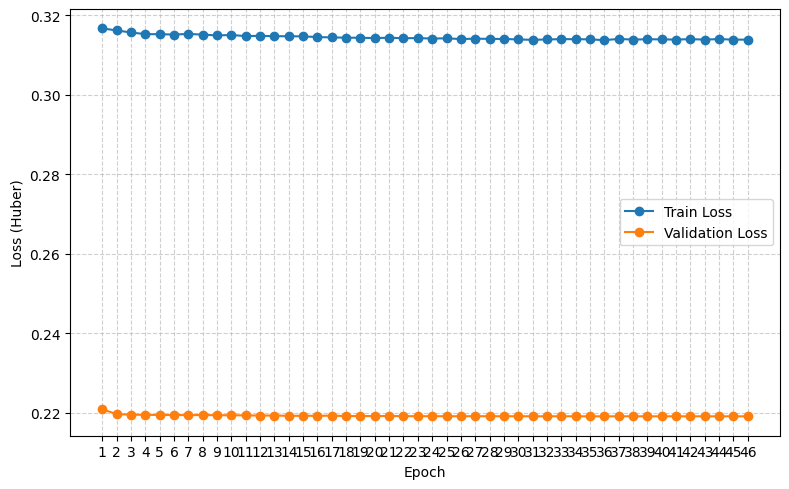

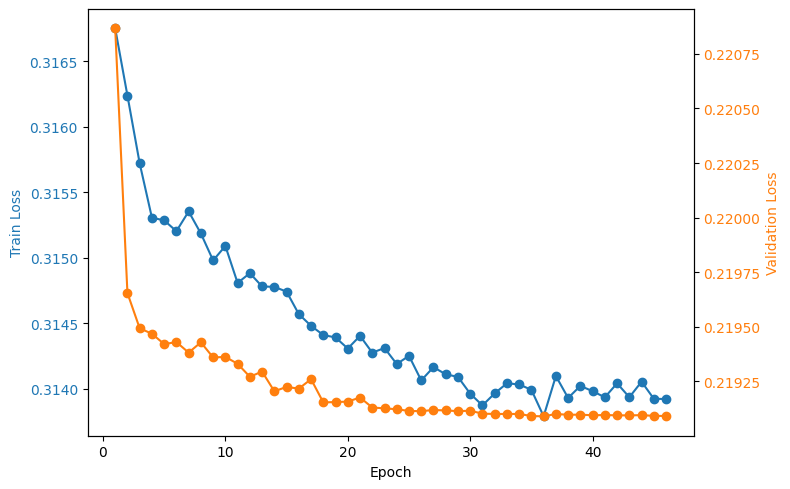

In [ ]:
# plot train loss / validation loss
train_loss_history = history.history['loss']
validation_loss_history = history.history['val_loss']
plot_train_validation_loss_by_epoch(train_loss_history, validation_loss_history)
 

In [ ]:
# predict
start = time.time()
y_train_predict = model.predict(X_train)
metrics["train_predict_ms"] = (time.time() - start)
start = time.time()
y_validation_predict = model.predict(X_validation)
metrics["validation_predict_ms"] = (time.time() - start)

start = time.time()
y_test_predict = model.predict(X_test)
metrics["test_predict_ms"] = (time.time() - start)

# append predictions to dataframes 
add_predictions_to_df(df_scaled_window_train, y_train_predict, target_scaler, df_scaled_window_train.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_validation, y_validation_predict, target_scaler, df_scaled_window_validation.iloc[0]["close"])
add_predictions_to_df(df_scaled_window_test, y_test_predict, target_scaler, df_scaled_window_validation.iloc[-1]["predict_close_accumulated"])


763/763 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [7]:
# eval metrics
metrics["train"] = evaluate_metrics_df(df_scaled_window_train)
metrics["validation"] = evaluate_metrics_df(df_scaled_window_validation)
metrics["test"] = evaluate_metrics_df(df_scaled_window_test)


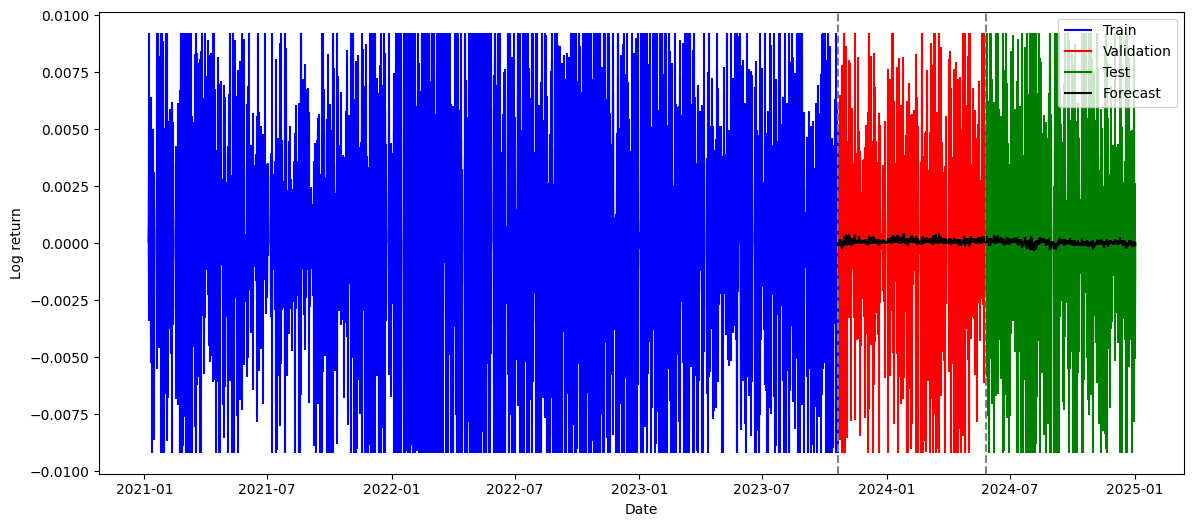

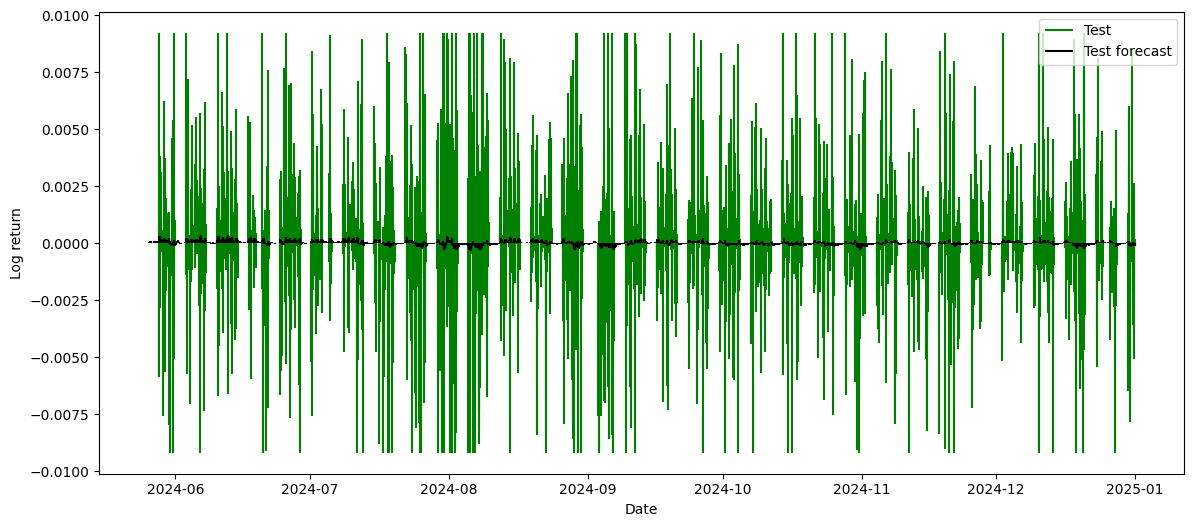

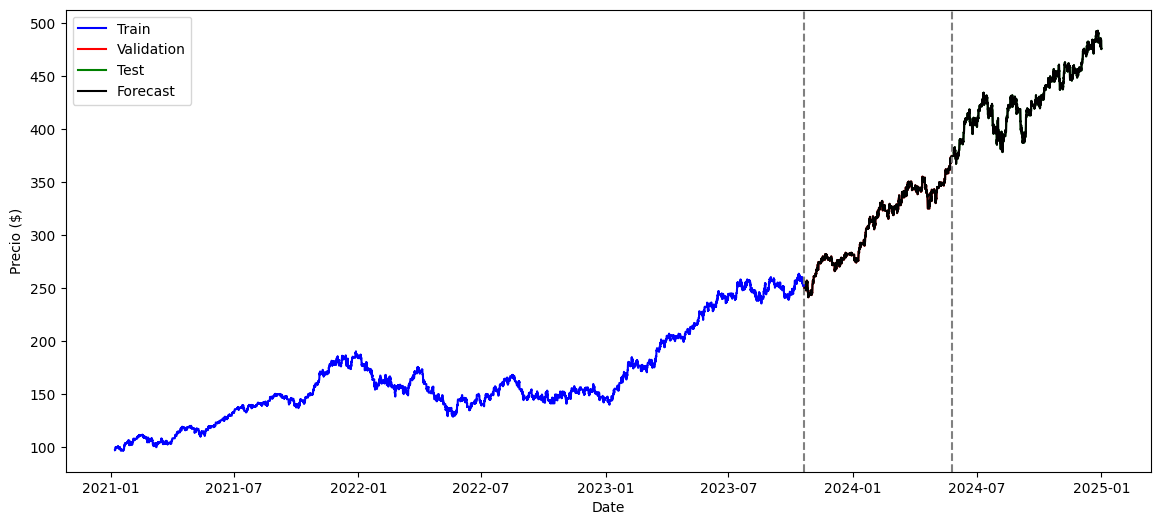

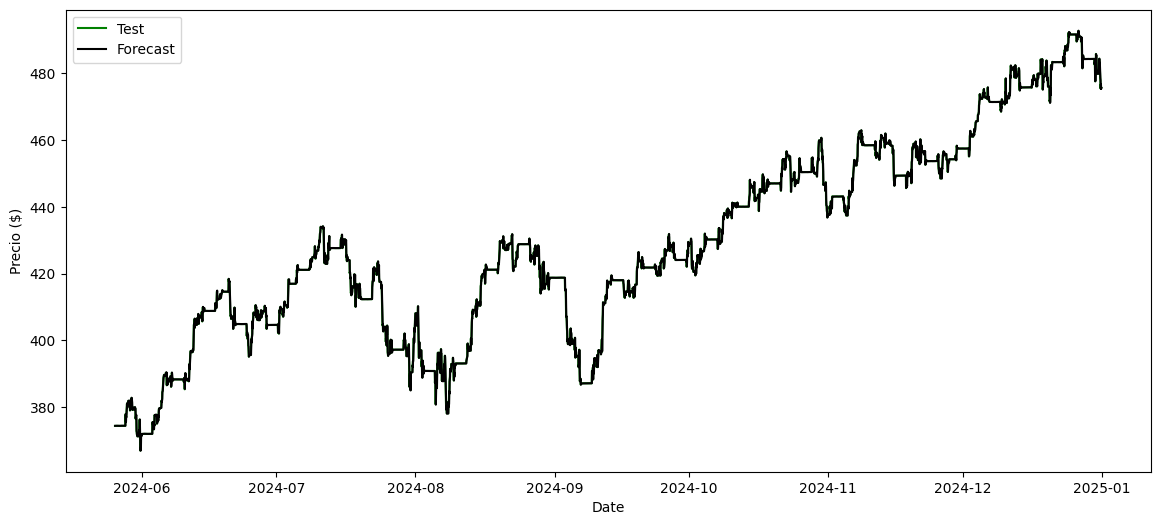

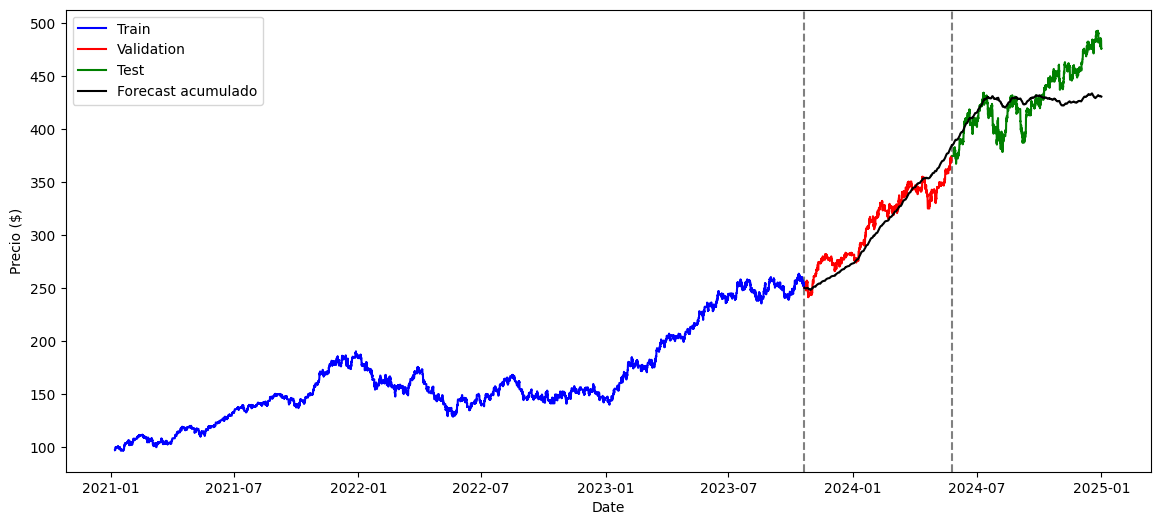

In [8]:
# plot
plot_df(df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test, False)

In [10]:
# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["target_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution TARGET:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")

# Suppose y_dir contains your direction labels (-1, 0, +1)
unique, counts = np.unique(df_scaled_window_test[["predict_direction"]].to_numpy(), return_counts=True)
probs = counts / counts.sum()

print("Class distribution PREDICT:")
for u, p in zip(unique, probs):
    print(f"{u}: {p:.2%}")    

Class distribution TARGET:
-1: 20.52%
0: 56.75%
1: 22.73%
Class distribution PREDICT:
-1: 7.08%
0: 74.90%
1: 18.01%


In [11]:
# estabilidad del model

# ANOVA test
anova_result = f_oneway(
    df_scaled_window_train["error_log_return"],
    df_scaled_window_validation["error_log_return"],
    df_scaled_window_test["error_log_return"]
)
metrics["anova"] = anova_result

# show
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)


F-statistic: 0.9609029889726363
p-value: 0.3825574105762485


In [12]:
# show metrics
print(json.dumps(metrics, indent=4) )

{
    "train_ms": 232.12019968032837,
    "train_predict_ms": 4.426541090011597,
    "validation_predict_ms": 0.9347574710845947,
    "test_predict_ms": 0.9382078647613525,
    "train": {
        "mse": 6.534247993527166e-06,
        "rmse": 0.0025562175168649414,
        "mae": 0.0012477701013994243,
        "huber": 3.267123996763583e-06,
        "r2": 0.00673363615909961,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.09251381907575595,
        "spearman_rho": 0.08931185183230597,
        "direction": 65.2216668032451,
        "sharpe": 0.05633214359342731
    },
    "validation": {
        "mse": 4.122342268536101e-06,
        "rmse": 0.0020303552074787557,
        "mae": 0.0009812184937331811,
        "huber": 2.0611711342680503e-06,
        "r2": 0.0021825470128842284,
        "mape": null,
        "smape": null,
        "aic": null,
        "bic": null,
        "pearson_r": 0.04694786574734382,
        "spearman_rho"

In [13]:
# save 
save_result("TSFEDL", metrics, df_scaled_window_train, df_scaled_window_validation, df_scaled_window_test)